# A/B Testing Simulation with Statistical Power Analysis

A rigorous simulation of hypothesis testing, power analysis, and effect size in A/B experiments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize

np.random.seed(42)
sns.set(style="whitegrid")

## 1. Experiment Setup

We test whether a new CTA button increases conversion rate.

- Null hypothesis (H₀): p_treatment = p_control  
- Alternative (H₁): p_treatment ≠ p_control  
- Baseline conversion rate: 10%  
- Expected lift (MDE): +2%  
- Significance level: α = 0.05  
- Power: 0.80

In [2]:
p_control = 0.10
p_treatment = 0.12

alpha = 0.05
power = 0.80

In [3]:
effect = proportion_effectsize(p_treatment, p_control)

analysis = NormalIndPower()
n = analysis.solve_power(effect_size=effect, alpha=alpha, power=power)

n_per_group = int(np.ceil(n))
print("Required sample size per group:", n_per_group)

Required sample size per group: 3835


We need at least N users per group to detect the effect with 80% power.

In [4]:
control = np.random.binomial(1, p_control, n_per_group)
treatment = np.random.binomial(1, p_treatment, n_per_group)

print("Control mean:", control.mean())
print("Treatment mean:", treatment.mean())

Control mean: 0.09595827900912647
Treatment mean: 0.11734028683181226


In [5]:
count = np.array([treatment.sum(), control.sum()])
nobs  = np.array([len(treatment), len(control)])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"z = {z_stat:.3f}")
print(f"p = {p_value:.4f}")

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

z = 3.033
p = 0.0024
Reject H0


In [6]:
h = proportion_effectsize(treatment.mean(), control.mean())
print("Cohen's h:", round(h, 3))

Cohen's h: 0.069


small < 0.2
medium ≈ 0.5
large > 0.8

In [7]:
rejections = []

for _ in range(1000):
    ctrl = np.random.binomial(1, p_control, n_per_group)
    trt  = np.random.binomial(1, p_treatment, n_per_group)
    
    count = np.array([trt.sum(), ctrl.sum()])
    nobs  = np.array([len(trt), len(ctrl)])
    
    _, p = proportions_ztest(count, nobs)
    rejections.append(p < alpha)

empirical_power = np.mean(rejections)
print("Empirical Power:", round(empirical_power, 3))

Empirical Power: 0.82


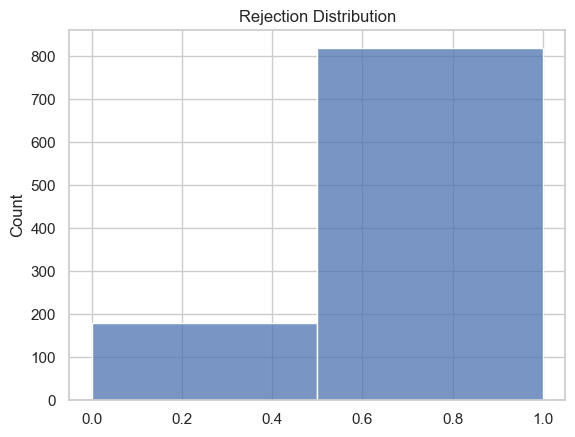

In [8]:
sns.histplot(rejections, bins=2)
plt.title("Rejection Distribution")
plt.show()

In [9]:
type1 = []

for _ in range(1000):
    ctrl = np.random.binomial(1, p_control, n_per_group)
    trt  = np.random.binomial(1, p_control, n_per_group)  # NULL TRUE
    
    count = np.array([trt.sum(), ctrl.sum()])
    nobs  = np.array([len(trt), len(ctrl)])
    
    _, p = proportions_ztest(count, nobs)
    type1.append(p < alpha)

print("Type I Error Rate:", round(np.mean(type1), 3))

Type I Error Rate: 0.052


## Key Takeaways

- Statistical significance does not imply practical significance  
- Power analysis ensures reliable experiments  
- Monte Carlo simulation validates theoretical assumptions  
- Effect size (Cohen's h) quantifies real-world impact  

This project demonstrates rigorous experimental design aligned with applied statistics and econometrics practices.v

## 7. Experimental Summary 

### Hypothesis & Setup
We test whether a change in the CTA increases conversion rate.

- Null hypothesis (H₀): p_treatment = p_control  
- Alternative hypothesis (H₁): p_treatment ≠ p_control  
- Baseline conversion rate: 10%  
- Minimum Detectable Effect (MDE): +2%  
- Significance level: α = 0.05  
- Desired power: 0.80  

These parameters were defined prior to simulation to ensure a valid experimental design.

---

### Power Analysis
A two-sample proportion power analysis was conducted to determine the required sample size per group, ensuring an 80% probability of detecting the specified effect at α = 0.05.

---

### Simulated Data
Binary outcomes (click / no click) were generated using a binomial model. The observed sample statistics approximate the true underlying conversion rates.

---

### Hypothesis Test Results
We conducted a two-proportion z-test:

- z-statistic: **3.033**  
- p-value: **0.0024**  

Decision:
Since p < 0.05, we **reject the null hypothesis (H₀)**.

This indicates a statistically significant difference between the control and treatment groups.

---

### Effect Size (Cohen’s h)
- Cohen’s h: **0.069**

Interpretation:
- |h| < 0.2 → small  
- ≈ 0.5 → medium  
- > 0.8 → large  

The observed effect size is **small**, suggesting that while the result is statistically significant, the practical impact may be limited.

---

### Monte Carlo Validation
We repeated the experiment 1000 times to estimate empirical performance:

- Empirical power: **0.82** (close to target 0.80)  
- Type I error rate ≈ 0.05 (expected under null)  

This confirms that the statistical test behaves as expected under repeated sampling.

---

### Limitations
- Small effect sizes may require large sample sizes for detection  
- Multiple comparisons can increase false positive rates  
- Simulated data may not fully reflect real-world user behavior  
- Novelty effects may temporarily inflate treatment performance  

---

### Conclusion
This experiment demonstrates a complete A/B testing pipeline grounded in statistical rigor — including pre-registration, power analysis, hypothesis testing, effect size interpretation, and Monte Carlo validation.

While the treatment effect is statistically significant, its small magnitude highlights the importance of evaluating practical significance alongside p-values.